## Import libraries

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm


import sys, os
sys.path.append(os.path.join(os.getcwd(), "../rctorch"))


from rctorch.models import MorrisLecar, MorrisLecarCurrent
from rctorch import Reservoir
from rctorch.utils import minmax_transform, z_transform

In [2]:
mpl.rcParams["font.family"] = "Nimbus Roman"

mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 14
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["figure.titlesize"] = 16
mpl.rcParams["figure.labelsize"] = 18
mpl.rcParams["font.style"] = "normal"
mpl.rcParams["legend.fontsize"] = 12
mpl.rcParams["legend.title_fontsize"] = 12

## Preparations for Lorenz Attractor

In [3]:
def gen_noise(n_trials:int, dt, noise_amp:float=5.0, min_time:float=500.0, max_time:float=1000.0):
    noise_signal = []
    # Generate noise
    for i in range(n_trials):
        noise = np.random.uniform(-noise_amp, noise_amp, size=1)[0]
        duration = np.random.uniform(min_time, max_time, size=1)[0]
        nt_noise = int(duration/dt)
        noise_signal.extend([noise]*nt_noise)
    return np.array(noise_signal)

In [4]:
def gen_bifurcation_data(noise_signal:np.ndarray, dt:float=1e-1, tau:float=0.01, mu:float=3.0, x0:float=0.1):
    nt = noise_signal.shape[0]
    x = x0
    x_rec = np.zeros((nt, 1))
        
    for i in tqdm(range(nt)):
        x_dot = mu * x - (x**3) + noise_signal[i]
        x += x_dot * dt * tau
        x_rec[i, 0] = x
    return x_rec

In [5]:
seed = 1
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.random.manual_seed(seed)


dt = 1e-1

# Generate noise
noise = gen_noise(n_trials=70, dt=dt, noise_amp=2.0, min_time=500.0, max_time=1000.0)
x = gen_bifurcation_data(noise, dt=dt, tau=0.02, mu=2., x0=0.1)

sup = minmax_transform(x, zero_mean=True)
print(sup.shape)

noise_signal = minmax_transform(noise, zero_mean=True)

nt = sup.shape[0]
T = nt * dt
time = np.arange(0, T, dt)

100%|██████████| 534917/534917 [00:00<00:00, 2239412.33it/s]

(534917, 1)


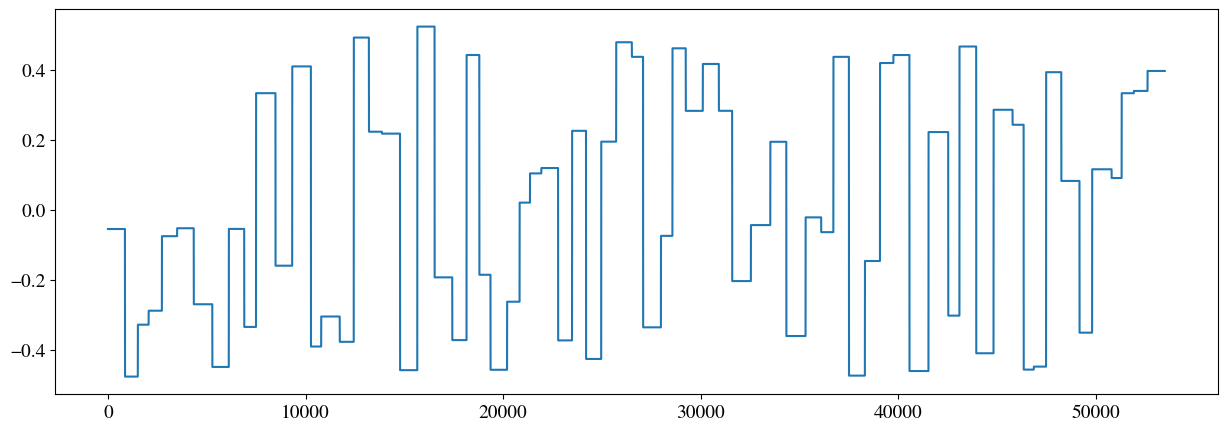

In [6]:
fig = plt.figure(figsize=(15, 5))
plt.plot(time, noise_signal)
plt.show()

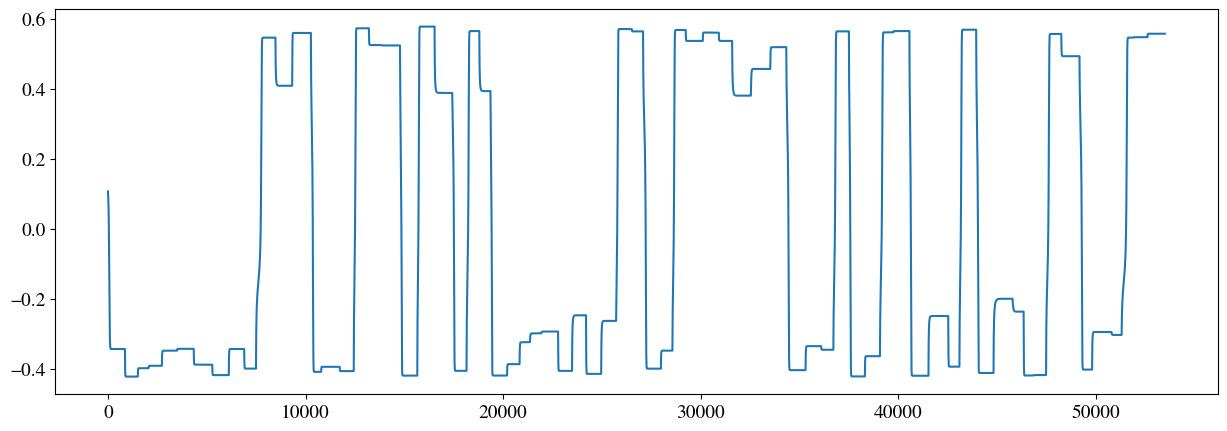

In [7]:
plt.figure(figsize=(15, 5))
plt.plot(time, sup[:, 0])
plt.show()

# ML Model

In [8]:
NE = 400
NI = 100
N = NI + NE

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")

# input current for I and E neurons
Ie = 65     # pA
Ii = 65     # pA
current = np.array([Ie] * NE + [Ii] * NI).reshape(N, 1)
current_tensor = torch.tensor(current, dtype=torch.float32).to(device)
noise_tensor = torch.tensor(noise_signal, dtype=torch.float32).to(device)

Q = 200
lamda = 1.0
gbar = 20
sparse = 0.01

Using Device <cuda> for PyTorch computations...



In [9]:
torch.cuda.random.manual_seed(seed)
res = None
dim = sup.shape[1]
try:
    res = Reservoir(
        model_cls=MorrisLecarCurrent, n_input=dim, n_output=dim, w_in_amp=Q, BIAS=current, dt=dt, 
        p_sparsity=sparse,
        Ne=NE, Ni=NI, gbar=gbar, device=device,
        )
except Exception as e:
    print(e)
    print(torch.cuda.memory_summary(device=device))

In [10]:
# colors = plt.pcolormesh(ml.w.cpu().numpy(), cmap='viridis')
# plt.colorbar(colors)
# plt.show()
ml = res.model

print(f"Mean: {ml.w.type(dtype=torch.float64).mean().item()}, \nSTD: {ml.w.type(dtype=torch.float64).std().item()}")
print(f"Max: {ml.w.type(dtype=torch.float64).max().item()}, \nMin: {ml.w.type(dtype=torch.float64).min().item()}")

Mean: -0.0014411139516226975, 
STD: 0.44673227547786415
Max: 2.086024045944214, 
Min: -1.9736826419830322


In [11]:
eta = Q/2 * (2 * torch.rand((res.n_hidden, sup.shape[1]), device=device, dtype=torch.float32) - 1)

In [12]:
# RLS params
test_time = T * .5    # ms
rls_stop = T - test_time
rls_step = 5

memory_length = 5000    # ms
rls_gap = rls_step * dt
memory_coeff = memory_length / rls_gap
ff_coeff = 1 - 1 / memory_coeff

ff_coeff = 1
ff_coeff

1

In [13]:
save_path = os.path.join(os.getcwd(), "bifurcation_task", f"Q_{Q}_gbar_{gbar}_l_{lamda}_Ne_{NE}_Ni_{NI}")
os.makedirs(save_path, exist_ok=True)

def save_tensor(tensor, name):
    file_name = name + ".pt"
    torch.save(tensor, os.path.join(save_path, file_name))
    print(f"Saved {file_name} in {save_path}")
    
def load_tensor(save_path:str, name:str):
    file_name = os.path.join(save_path, name + ".pt")
    tensor = torch.load(os.path.join(save_path, file_name), weights_only=True)
    print(f"Loaded {file_name} from {save_path}")
    return tensor

In [14]:
duration = 100
nt_transient = int(duration / dt)

n_neurons = 10
neurons = np.random.choice(N, n_neurons, replace=False)
print(neurons)

ml.BIAS = current_tensor
print(f"Transient Period: {duration} ms")
for i in tqdm(range(nt_transient)):
    ml.forward(0)

[224 363  47 478 374 460 151  23 463 104]
Transient Period: 100 ms


100%|██████████| 1000/1000 [00:00<00:00, 3253.12it/s]


In [15]:

nt_train = int((T-test_time) / dt)
s_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
v_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
n_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
xhat_rec_train = torch.zeros((nt_train, sup.shape[1]), device=device, dtype=torch.float32)
dec_rec_train = torch.zeros((nt_train, n_neurons, sup.shape[1]), device=device, dtype=torch.float32)
sup_tensor = torch.tensor(sup, dtype=torch.float32).to(device)

res.Pinv = torch.eye(res.n_hidden, device=device, dtype=torch.float32) / lamda
print(f"Training Period: {T-test_time} ms")
for i in tqdm(range(nt_train)):
    x = sup_tensor[i].reshape(-1, 1)
    noise_input_ = eta @ noise_tensor[i].reshape(-1, 1)
    signal_input_ = res.W_in @ x
    ml.forward(noise_input_ + signal_input_)
    s_rec_train[i] = ml.s[neurons].ravel()
    v_rec_train[i] = ml.mem[neurons].ravel()
    n_rec_train[i] = ml.n[neurons].ravel()
    x_hat = res.W_out.T @ ml.s
    xhat_rec_train[i] = x_hat.ravel()
    dec_rec_train[i] = res.W_out[neurons]

    if i % rls_step == 0:
        res._rls(x=x, x_hat=x_hat, state=ml.s, ff_coeff=ff_coeff)

Training Period: 26745.850000000002 ms


100%|██████████| 267458/267458 [02:13<00:00, 2005.78it/s]


In [16]:
save_tensor(ml.w, "weights")
save_tensor(s_rec_train, "s_rec_train")
save_tensor(v_rec_train, "v_rec_train")
save_tensor(n_rec_train, "n_rec_train")
save_tensor(xhat_rec_train, "xhat_rec_train")
save_tensor(dec_rec_train, "dec_rec_train")

Saved weights.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Saved s_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Saved v_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Saved n_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Saved xhat_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Saved dec_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100


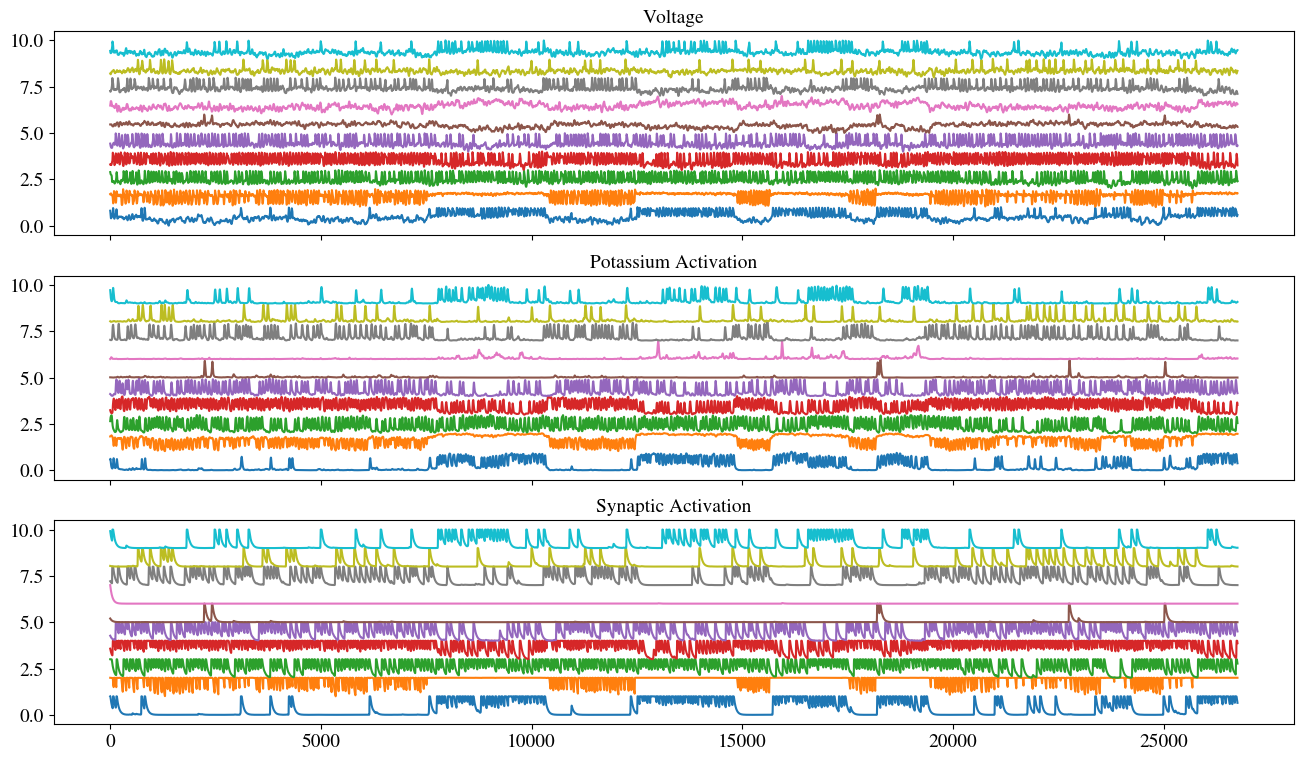

In [17]:
t_train = np.arange(nt_train) * dt

fig, ax = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for i in range(n_neurons):
    ax[0].plot(t_train, minmax_transform(v_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[1].plot(t_train, minmax_transform(n_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[2].plot(t_train, minmax_transform(s_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
ax[0].set_title('Voltage')
ax[1].set_title('Potassium Activation')
ax[2].set_title('Synaptic Activation')
plt.show()

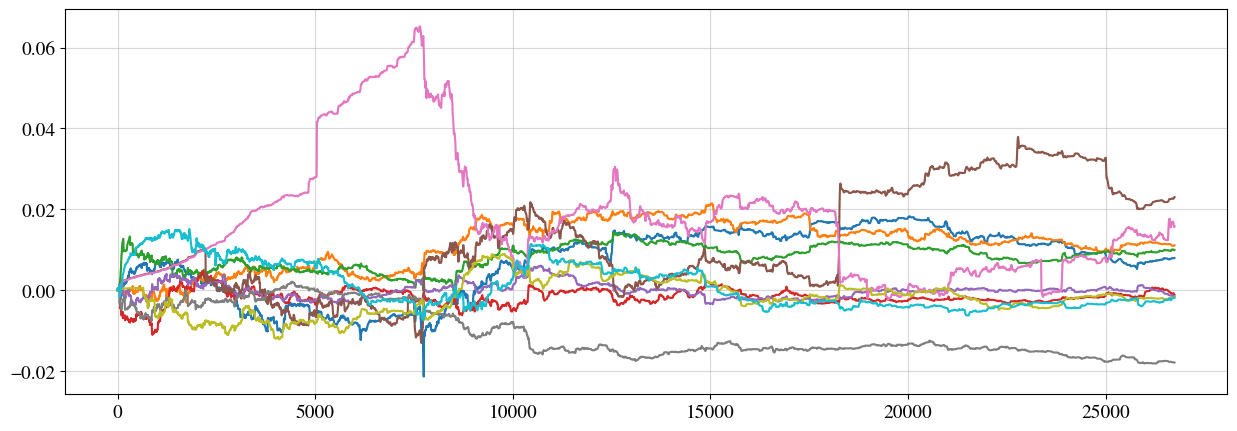

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

ax.plot(t_train, dec_rec_train[:, :, 0].cpu().numpy())
ax.grid(alpha=0.5)
plt.show()

In [19]:
res.W_out.abs().max().item()

0.2904183864593506

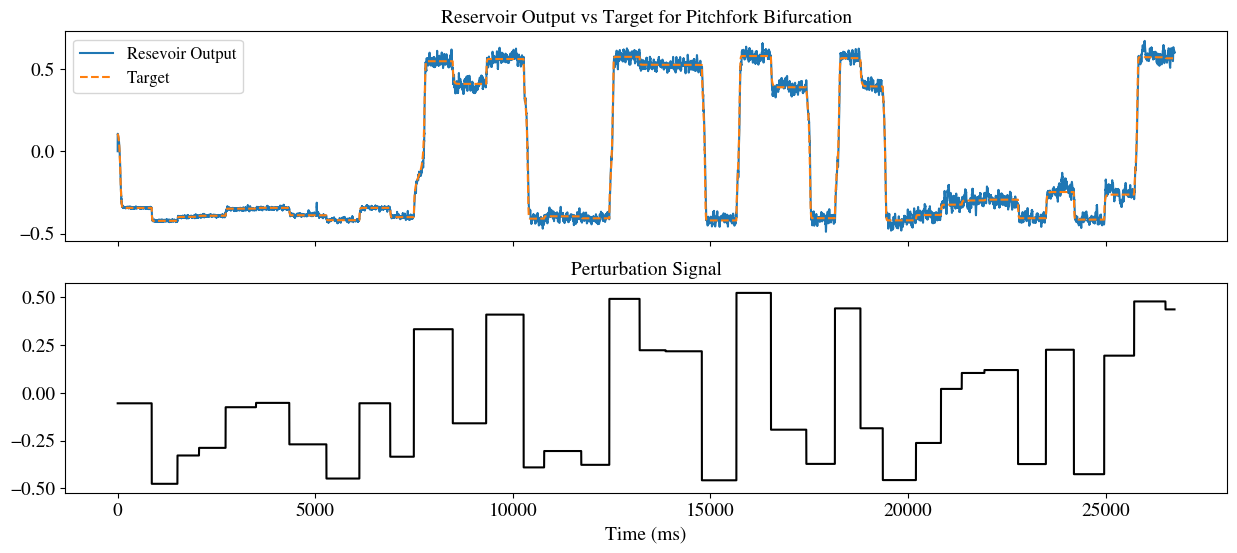

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
ax, ax2 = axes
ax.plot(t_train, xhat_rec_train[:, 0].cpu().numpy(), label='Resevoir Output')
ax.plot(t_train, sup[:nt_train, 0], '--', label='Target')
ax.set_title('Reservoir Output vs Target for Pitchfork Bifurcation')
ax.legend(loc='upper left')

ax2.plot(t_train, noise_signal[:nt_train], label='Perturbation Signal', color='k')
ax2.set_title('Perturbation Signal')
ax2.set_xlabel('Time (ms)')

plt.show()

In [21]:
nt_test = nt - nt_train
s_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
v_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
n_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
x_hat_rec = torch.zeros((nt_test, sup.shape[1]), device=device, dtype=torch.float32)

fb_matrix = res.W_in @ res.W_out.T
print(f"Testing Period: {test_time} ms")
for i in tqdm(range(nt_test)):
    input_ = fb_matrix @ ml.state() + eta @ noise_tensor[i + nt_train].reshape(-1, 1)
    ml.forward(input_)
    s_rec_test[i] = ml.s[neurons].ravel()
    v_rec_test[i] = ml.mem[neurons].ravel()
    n_rec_test[i] = ml.n[neurons].ravel()
    x_hat = res.W_out.T @ ml.s
    x_hat_rec[i] = x_hat.ravel()

Testing Period: 26745.850000000002 ms


100%|██████████| 267459/267459 [02:00<00:00, 2215.40it/s]


In [22]:
save_tensor(s_rec_test, "s_rec_test")
save_tensor(v_rec_test, "v_rec_test")
save_tensor(n_rec_test, "n_rec_test")
save_tensor(x_hat_rec, "x_hat_rec")

Saved s_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Saved v_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Saved n_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Saved x_hat_rec.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100


In [23]:
s_rec_test = load_tensor(save_path, "s_rec_test")
v_rec_test = load_tensor(save_path, "v_rec_test")
n_rec_test = load_tensor(save_path, "n_rec_test")
x_hat_rec = load_tensor(save_path, "x_hat_rec")

Loaded /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100/s_rec_test.pt from /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100/v_rec_test.pt from /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100/n_rec_test.pt from /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100/x_hat_rec.pt from /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_200_gbar_20_l_1.0_Ne_400_Ni_100


/home/ali/Apps/anaconda3/envs/ml/lib/python3.11/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


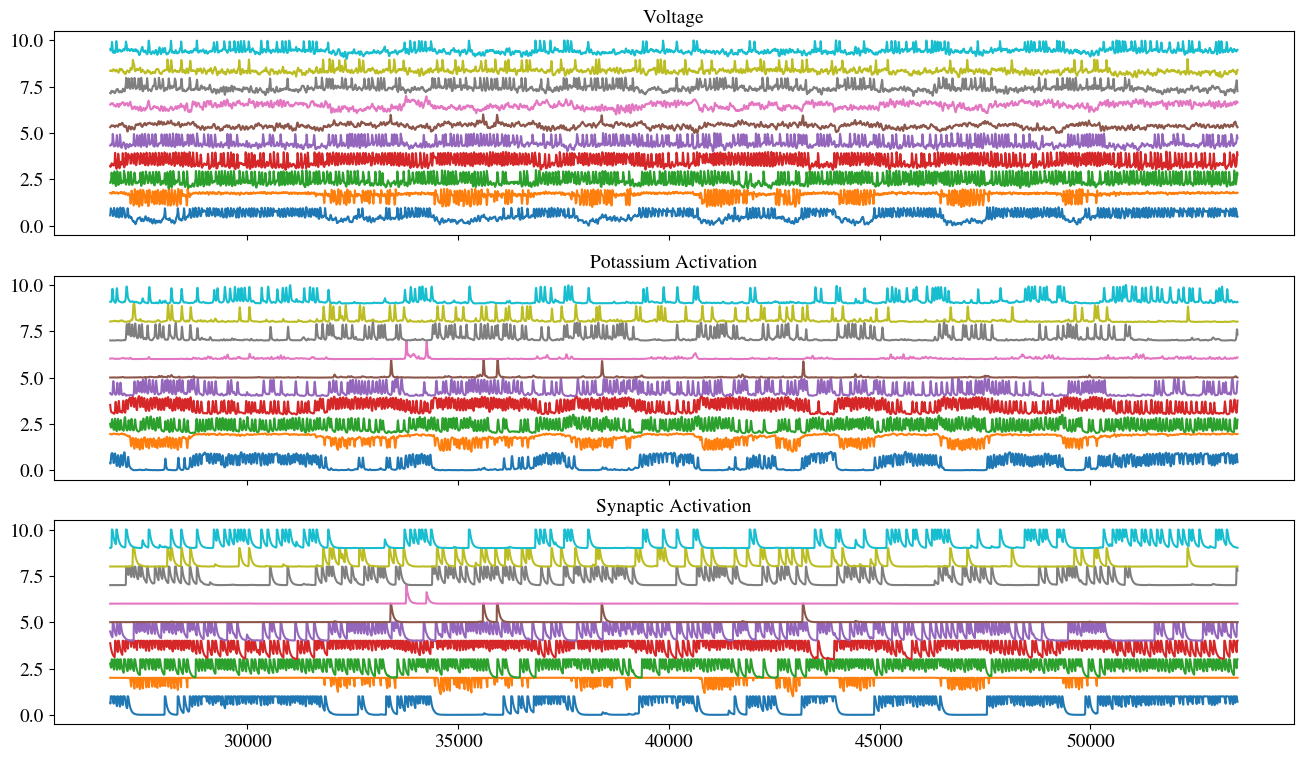

In [24]:
nt_test = s_rec_test.shape[0]
t_test = np.arange(nt_test) * dt + T - test_time
n_neurons = s_rec_test.shape[1]

fig, ax = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for i in range(n_neurons):
    ax[0].plot(t_test, minmax_transform(v_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[1].plot(t_test, minmax_transform(n_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[2].plot(t_test, minmax_transform(s_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
ax[0].set_title('Voltage')
ax[1].set_title('Potassium Activation')
ax[2].set_title('Synaptic Activation')
plt.show()

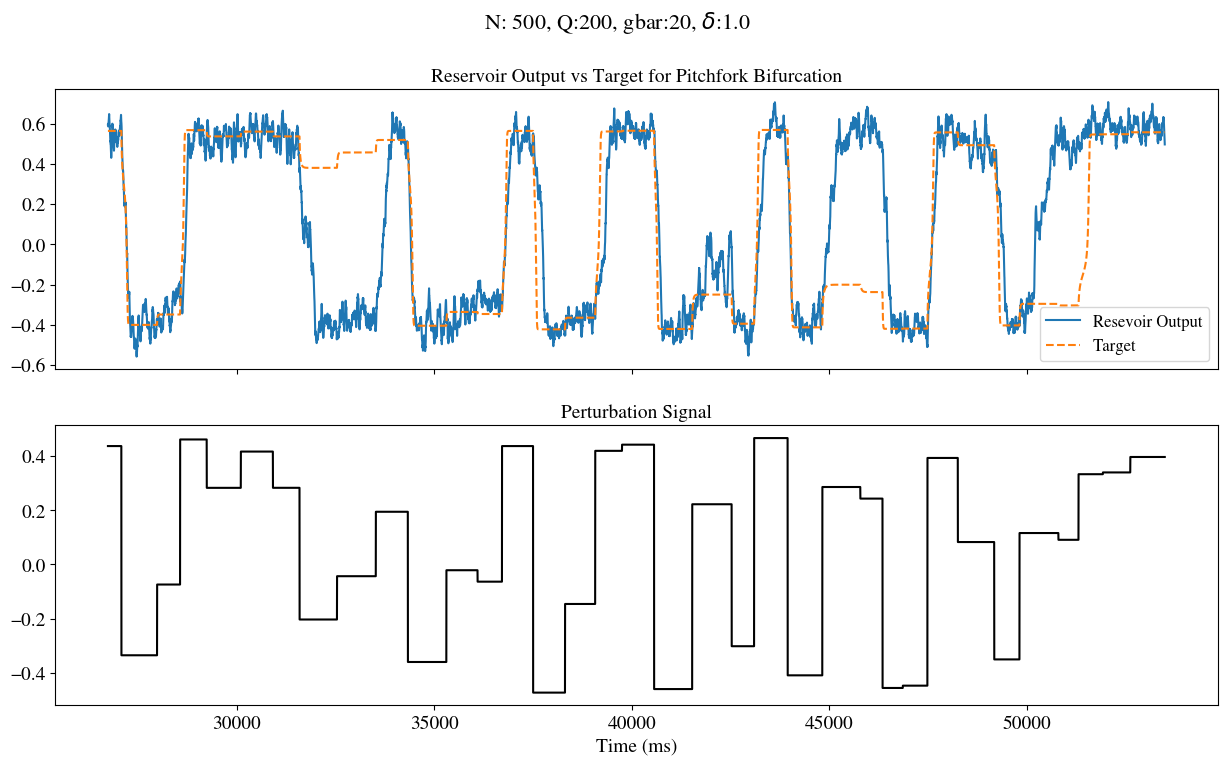

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ax, ax2 = axes

ax.plot(t_test, x_hat_rec[:, 0].cpu().numpy(), label='Resevoir Output')
ax.plot(t_test, sup[nt_train:, 0], '--', label='Target')
ax.set_title('Reservoir Output vs Target for Pitchfork Bifurcation')
ax.legend(loc='lower right')

ax2.plot(t_test, noise_signal[nt_train:], label='Perturbation Signal', color='k')
ax2.set_title('Perturbation Signal')
ax2.set_xlabel('Time (ms)')

plt.suptitle(fr"N: {ml.N}, Q:{Q}, gbar:{gbar}, $\delta$:{lamda}", fontsize=16)
plt.savefig(os.path.join(save_path, f"N_{ml.N}_ff_{ff_coeff}_timeseries.png"), dpi=300, bbox_inches='tight')
plt.show()

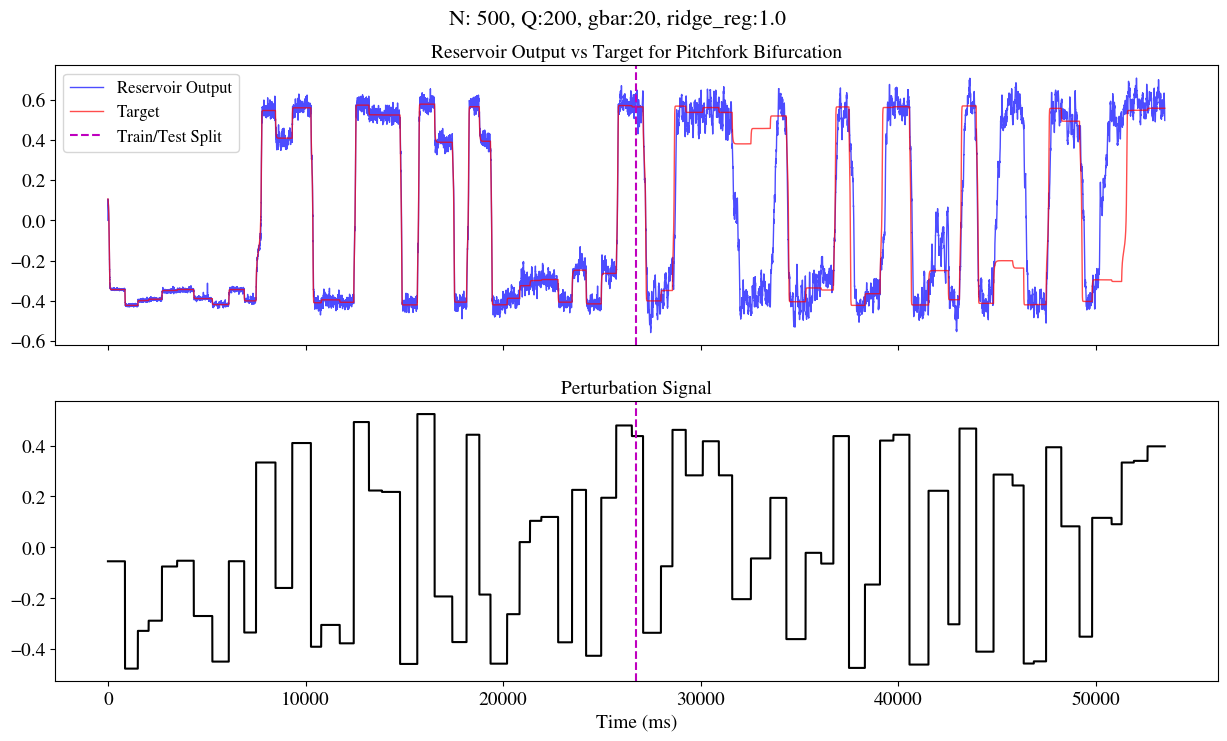

In [39]:
xhat_total = np.concatenate((xhat_rec_train.cpu().numpy(), x_hat_rec.cpu().numpy()), axis=0)

fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
out_line = ax[0].plot(time, xhat_total[:, 0], 'b-', lw=1, alpha=.7, label='Reservoir Output')
target_line = ax[0].plot(time, sup[:, 0], 'r-', lw=1, alpha=.7, label='Target')
ax[0].set_title('Reservoir Output vs Target for Pitchfork Bifurcation')
split_line = ax[0].axvline(x=t_train[-1], color='m', linestyle='--', label='Train/Test Split')
ax[0].legend(loc='upper left')

ax[1].plot(time, noise_signal, label='Perturbation Signal', color='k')
ax[1].set_title('Perturbation Signal')
ax[1].set_xlabel('Time (ms)')
# ax[1].legend(loc='upper right')
ax[1].axvline(x=t_train[-1], color='m', linestyle='--')
plt.suptitle(fr"N: {ml.N}, Q:{Q}, gbar:{gbar}, ridge_reg:{lamda}", y=0.95)
plt.savefig(os.path.join(save_path, f"N_{ml.N}_ff_{ff_coeff}_timeseries_total." + "png"), dpi=300, bbox_inches='tight')
plt.show()